# Simple example to illustrate the auto-correlation function of an integrated fibre optics signal from seismic ambient noise recordings
 
For a fibre described by kink points $x_i$, we compute a pairwise sum over Green's function arrival contributions between all kink pairs $(i, j)$. We use a homogeneous medium (P-wave velocity $v_P$ and S-wave velocity $v_S$ are constant throughout) so the travel times $t_P$ and $t_S$ are

$$
t_P = \frac{r_{ij}}{v_P}
$$

$$
t_S = \frac{r_{ij}}{v_S}
$$

where $r_{ij}$ is the Euclidean distance between kinks i and j.

The delta-like arrivals are approximated by Ricker wavelets so the result can be plotted as a smooth time series.

We use geometry-derived kink weights as a simple proxy for the directional sensitivity vector $a(s)$. 

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from itertools import product
from typing import Iterable, Sequence
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Input of the fibre geometry

In [2]:

@dataclass
class FiberGeometry:

    points: np.ndarray 
    @classmethod
    def from_points(cls, points: ArrayLike2D) -> "FiberGeometry":
        arr = np.asarray(points, dtype=float)
        if arr.ndim != 2 or arr.shape[1] != 2:
            raise ValueError("points must be an array-like of shape (N, 2).")
        if arr.shape[0] < 2:
            raise ValueError("Need at least two points to define a fibre geometry.")
        return cls(arr)

    @property
    def num_kinks(self) -> int:
        return self.points.shape[0]

    def segment_vectors(self) -> np.ndarray:
        return np.diff(self.points, axis=0)

    def segment_lengths(self) -> np.ndarray:
        vecs = self.segment_vectors()
        return np.linalg.norm(vecs, axis=1)

    def arc_lengths(self) -> np.ndarray:
        lengths = self.segment_lengths()
        s = np.zeros(self.num_kinks)
        s[1:] = np.cumsum(lengths)
        return s

    def unit_tangents(self) -> np.ndarray:
        vecs = self.segment_vectors()
        lengths = np.linalg.norm(vecs, axis=1)
        if np.any(lengths == 0):
            raise ValueError("Consecutive fibre points.")
        return vecs / lengths[:, None]

    def kink_weights_from_geometry(self) -> np.ndarray:

        n = self.num_kinks
        tangents = self.unit_tangents()
        w = np.ones(n, dtype=float)  # endpoints default to 1.0

        # interior kinks: turning angle between adjacent segment tangents
        for i in range(1, n - 1):
            t_in = tangents[i - 1]
            t_out = tangents[i]
            cos_theta = np.clip(np.dot(t_in, t_out), -1.0, 1.0)
            w[i] = np.arccos(cos_theta)  # turning angle in radians

        # Avoiding exact zeros for locally straight interior segments
        w[w == 0] = 1e-12
        return w



We define the Ricker wavelet to simulate the Green's function.

In [3]:
def ricker_wavelet(t: np.ndarray, t0: float, f0: float) -> np.ndarray:

    if f0 <= 0:
        raise ValueError("f0 must be positive.")
    u = (np.pi * f0 * (t - t0)) ** 2
    return (1.0 - 2.0 * u) * np.exp(-u)


We now define the autocorrelation time series as a sum of Ricker wavelets.

In [4]:
def pairwise_green_time_series(
    geometry: FiberGeometry,
    medium: HomogeneousMedium,
    samples_per_period: int = 20,
    f0: float = 100.0,
    include_self_pairs: bool = False,
    normalize: bool = False,
    min_distance: float = 1e-12,
    padding: float = 1.2,
    min_samples: int = 1000) -> np.ndarray:

    pts = geometry.points
    weights = geometry.kink_weights_from_geometry()
    n = geometry.num_kinks

    max_dist = max(
        float(np.linalg.norm(pts[i] - pts[j]))
        for i in range(n) for j in range(i + 1, n)
    )
    t_max = (max_dist / medium.vs) * padding
    dt = 1.0 / (samples_per_period * f0)
    n_samples = max(min_samples, int(np.ceil(t_max / dt)) + 1)
    t = np.linspace(0.0, t_max, n_samples)

    c_t = np.zeros_like(t, dtype=float)

    for i in range(n):
        for j in range(n):

            if not include_self_pairs and i == j:
                continue

            r_ij = float(np.linalg.norm(pts[i] - pts[j]))

            if i == j:
                # Self-arrival at t = 0; no geometric spreading.
                amp_ij = weights[i] ** 2
                c_t += amp_ij * medium.ap * ricker_wavelet(t, 0.0, f0)
                c_t += amp_ij * medium.as_ * ricker_wavelet(t, 0.0, f0)
                continue

            # Skip coincident but distinct points.
            if r_ij < min_distance:
                continue

            spreading = 1.0 / (r_ij ** medium.geometric_spreading_power)
            amp_ij = weights[i] * weights[j] * spreading

            t_p = r_ij / medium.vp
            t_s = r_ij / medium.vs

            c_t += amp_ij * medium.ap * ricker_wavelet(t, t_p, f0)
            c_t += amp_ij * medium.as_ * ricker_wavelet(t, t_s, f0)

    if normalize:
        max_amp = np.max(np.abs(c_t))
        if max_amp > 0:
            c_t /= max_amp

    return c_t, t


We also define the homogeneous medium properties:

In [5]:
@dataclass(frozen=True)
class HomogeneousMedium:

    vp: float 
    vs: float 
    ap: float = 1.0 
    as_: float = 1.0 
    geometric_spreading_power: float = 1.0 

    def __post_init__(self) -> None:
        if self.vp <= 0 or self.vs <= 0:
            raise ValueError("vp and vs must be positive.")
        if self.vs >= self.vp:
            raise ValueError("For a standard elastic medium, require vs < vp.")
        if self.geometric_spreading_power < 0:
            raise ValueError("geometric_spreading_power must be non-negative.")

Some plotting function to visualise the results

In [6]:

def plot_geometry_and_response(
    geometry: FiberGeometry,
    medium: HomogeneousMedium,
    t: np.ndarray,
    c_t: np.ndarray,
    title: str = "Fibre autocorrelation",
) -> None:

    pts = geometry.points
    weights = geometry.kink_weights_from_geometry()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    # Geometry panel
    ax = axes[0]
    ax.plot(pts[:, 0], pts[:, 1], "k-o", lw=2, ms=5)
    for i, (x, y) in enumerate(pts):
        ax.annotate(f"s{i+1}\n(w={weights[i]:.2f})", (x, y), textcoords="offset points", xytext=(6, 6))
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Fibre geometry")
    ax.grid(True, alpha=0.3)

    # Response panel
    ax = axes[1]
    ax.plot(t, c_t, lw=1.5, color="k", zorder=3)

    # Vertical lines at expected P- and S-wave arrival times for each kink pair
    n_pts = geometry.num_kinks
    first_p = True
    first_s = True
    xform = ax.get_xaxis_transform()  
    for i in range(n_pts):
        for j in range(i + 1, n_pts):
            r_ij = float(np.linalg.norm(pts[i] - pts[j]))
            if r_ij < 1e-12:
                continue
            pair = f"s{i+1}-s{j+1}"
            t_p = r_ij / medium.vp
            t_s = r_ij / medium.vs
            ax.axvline(t_p, color="b", lw=0.9, ls="--", alpha=0.75,
                       label="P arrivals" if first_p else "_nolegend_")
            ax.axvline(t_s, color="orange", lw=0.9, ls=":", alpha=0.75,
                       label="S arrivals" if first_s else "_nolegend_")
            ax.text(t_p, 0.97, pair, transform=xform, fontsize=7,
                    ha="center", va="top", color="b", rotation=90)
            ax.text(t_s, 0.97, pair, transform=xform, fontsize=7,
                    ha="center", va="top", color="orange", rotation=90)
            first_p = False
            first_s = False

    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlabel("Time [s]")
    ax.set_ylim(-0.01, 0.01)
    ax.set_ylabel("Green's function amplitude")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    fig.suptitle(
        f"Homogeneous medium: vp={medium.vp:g} km/s, vs={medium.vs:g} km/s",
        fontsize=12,
    )
    plt.show()


We now call our functions with arbitrary fibre geometry and medium parameters.

In [7]:
# Simple cable geometry

points = [
        (0.0, 0.0),   # s1
        (10.0, 0.0),   # s2
        (5, 8),   # s3\
        (4, 8),   # s3
        (17, 2),   # s3
    ]

geometry = FiberGeometry.from_points(points)

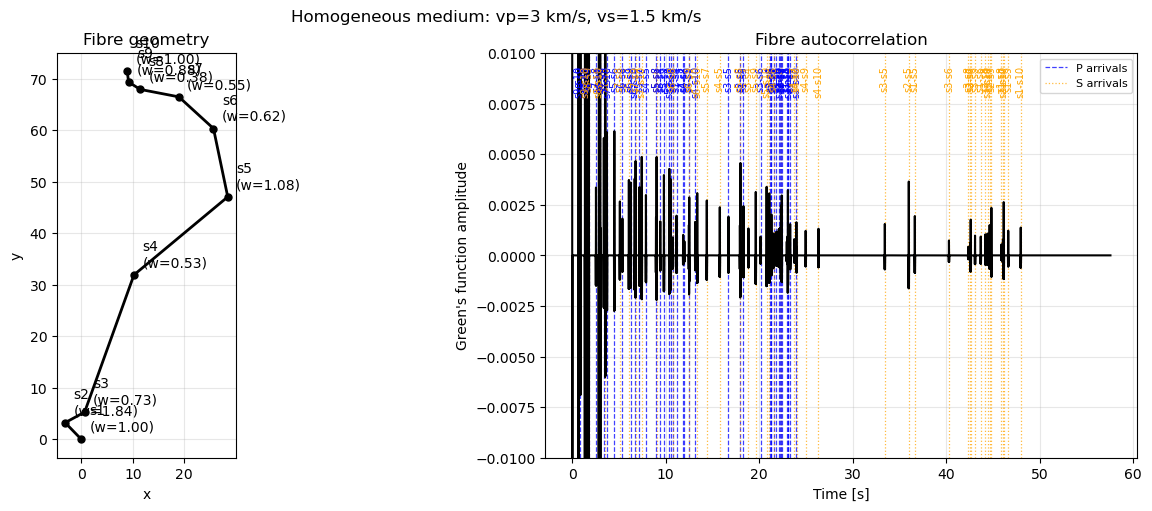

In [8]:
# Load fiber coordinates from CSV
data = pd.read_csv("fibre_coordinates.csv")

latlon = data[["Latitude", "Longitude"]].values.astype(float)

# Convert lat/lon (degrees) to local Cartesian coordinates (km)

R = 6371.0  # Earth radius (km)
lat = np.radians(latlon[:, 0])
lon = np.radians(latlon[:, 1])
lat0 = lat[0]
lon0 = lon[0]

x = R * (lon - lon0) * np.cos(lat0)   # Easting (km)
y = R * (lat - lat0)                  # Northing (km)
points = np.column_stack((x, y))

geometry = FiberGeometry.from_points(points)

medium = HomogeneousMedium(vp=3.0, vs=1.5, ap=1.0, as_=0.8, geometric_spreading_power=1.0)


f0 = 20.0



c_t, t = pairwise_green_time_series(
    geometry=geometry,
    medium=medium,
    f0=f0,
    include_self_pairs=True,
    normalize=True,
)

plot_geometry_and_response(geometry, medium, t, c_t)
